#### Checking if all SUMO HOME configs are correctly installed

In [1]:
import os
import sys

if "SUMO_HOME" in os.environ:
    print("SUMO_HOME environment variable is set to:", os.environ["SUMO_HOME"])
else:
    print("Error: SUMO_HOME environment variable is not set.")

SUMO_HOME environment variable is set to: D:\SUMO


In [ ]:
## Terminal command to check if routing for network is correct : 
## python "$env:SUMO_HOME\tools\route\routecheck.py" unrestricted_right.net.xml routes.rou.xml

import os
import sys
import subprocess
import sumolib
frpm pathlib import Path

folder_name = "unrestricted_right_xml_gen"
net_name = "unrestricted_right"

net_file     = Path().joinpath("..", "nets",  folder_name, f"{net_name}.net.xml")
route_file    = Path().joinpath("..", "nets",  folder_name, "routes.rou.xml")
out_csv_name    = Path().joinpath("..", "outputs",  "sumo_rl_outputs")

# ── Check SUMO_HOME ───────────────────────────────────────────────────────────
print("SUMO_HOME:", os.environ.get("SUMO_HOME", "NOT SET "))

# ── Check sumolib resolves the binary ─────────────────────────────────────────
try:
    sumo_binary = sumolib.checkBinary("sumo")
    print(f"sumo binary : {sumo_binary}")
except Exception as e:
    print(f"sumolib.checkBinary failed: {e} → Check if SUMO is installed and SUMO_HOME is set correctly.")

# ── Check your files exist ────────────────────────────────────────────────────
print(f"\nnet_file   exists: {Path(net_file).exists()}   → {net_file}")
print(f"route_file exists: {Path(route_file).exists()} → {route_file}")


Traffic config — 2 vehicle type(s):
  [standard] speed=13.89 m/s | friction=1.0 | sigma=0.5 | SSM=['TTC', 'DRAC', 'PET']
  [cautious] speed=8.33 m/s | friction=1.0 | sigma=0.1 | SSM=['TTC', 'DRAC', 'PET']
✓ Traffic config written → ..\nets\unrestricted_right_xml_gen\vehicle_types.add.xml
Using cpu device
✓ Built PPO | hyperparams: {'learning_rate': 0.0003, 'n_steps': 512, 'batch_size': 64, 'n_epochs': 10, 'gamma': 0.99, 'gae_lambda': 0.95, 'ent_coef': 0.01}
✓ StepLogger initialised → d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\causal\steps.csv
Logging to d:\Robotic_Sensing_and Transfer_Learning\Simulation\outputs\logs\PPO1\PPO_1
----------------------------
| time/              |     |
|    fps             | 87  |
|    iterations      | 1   |
|    time_elapsed    | 5   |
|    total_timesteps | 512 |
----------------------------
  Episode 001 | reward: -73.856 | collisions: 1 | mean_speed: 28.496
-----------------------------------------
| rollout/                |     

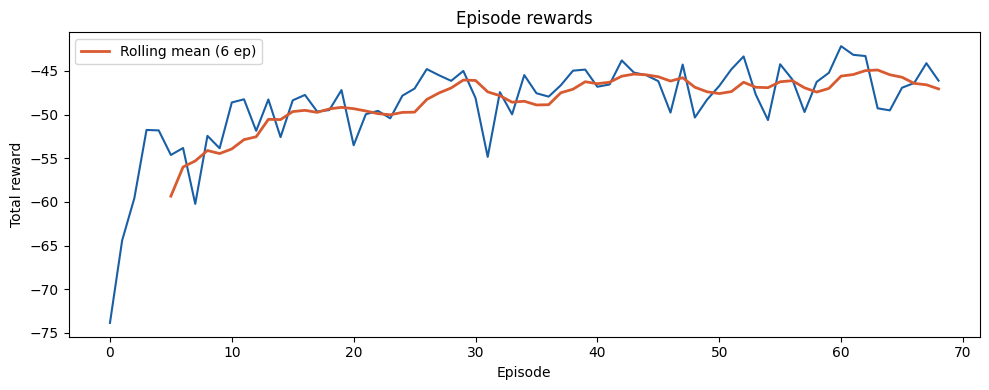

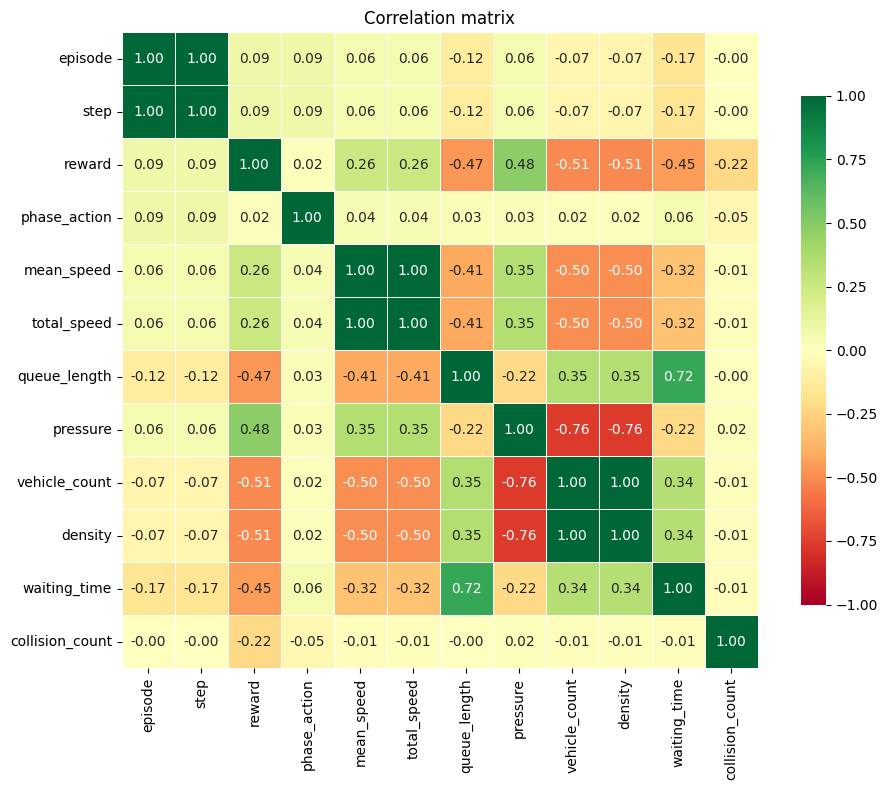

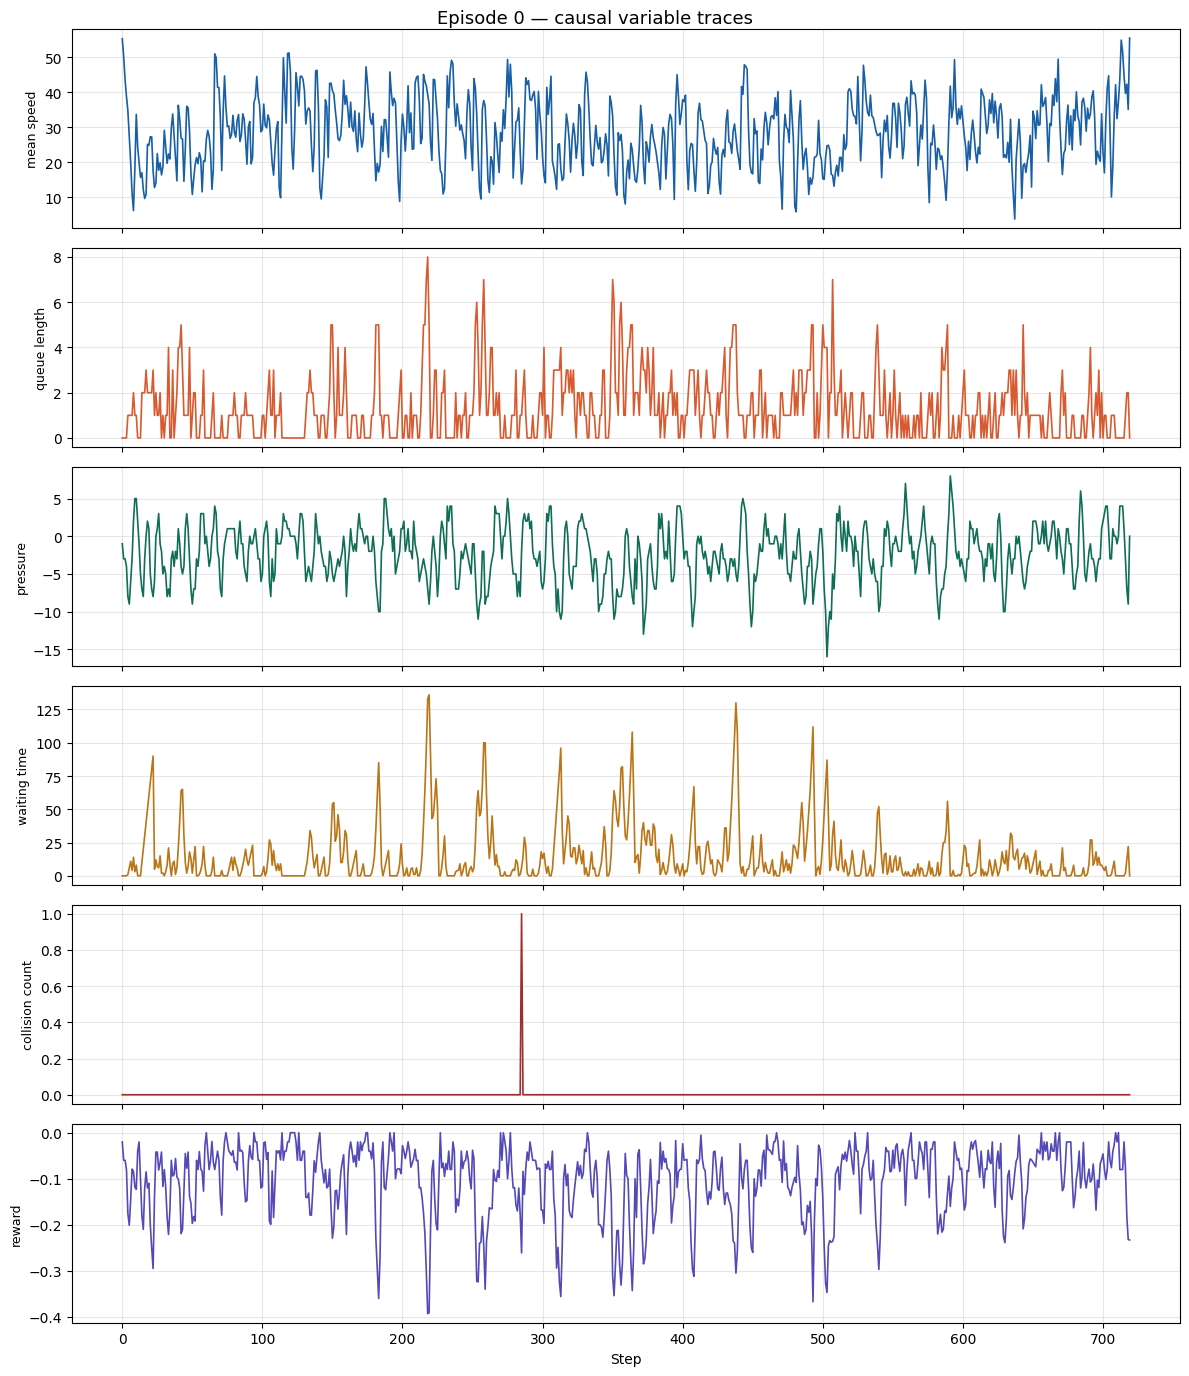

Plotly not available.


In [ ]:
# ── Cell 1: imports ────────────────────────────────────────────────────────────
import sys
sys.path.append("../src")

from environment1      import EnvironmentConfig, make_env, make_env_pair
from traffic_config   import TrafficConfig, VehicleTypeConfig
from agent            import AgentConfig, AgentBuilder
from rewards          import get_reward_fn
from observations     import get_observation_class
from logging_module   import StepLogger, EpisodeSummaryLogger, CausalLoggingCallback
from plotting         import (plot_episode_rewards, plot_correlation_heatmap,plot_causal_variables, plotly_training_dashboard)
from stable_baselines3.common.vec_env import DummyVecEnv
from pathlib import Path

# ── Cell 2: traffic config ─────────────────────────────────────────────────────
traffic = TrafficConfig(output_dir="../nets/unrestricted_right_xml_gen")
traffic.add_preset("standard").add_preset("cautious")   # heterogeneous mix
traffic.summary()
add_file = traffic.write()

# ── Cell 3: environment config ─────────────────────────────────────────────────
base = Path.cwd().parent
cfg  = EnvironmentConfig(
    net_file     = str(base / "nets/unrestricted_right_xml_gen/unrestricted_right.net.xml"),
    route_file   = str(base / "nets/unrestricted_right_xml_gen/unrestricted_right.rou.xml"),
    out_csv_name = str(base / "outputs/results/PPO/sumo_output"),
    duration     = 3600,
    additional_sumo_cmd = ["--additional-files", add_file],
)
reward_fn   = get_reward_fn("weighted")
obs_class   = get_observation_class("default")

train_fn, eval_fn = make_env_pair(
    train_config = cfg,
    eval_config  = cfg,    # swap for different vehicle config to test generalisation
    reward_fn    = reward_fn,
    observation_class = obs_class,
)
train_env = DummyVecEnv([train_fn])
eval_env  = DummyVecEnv([eval_fn])

# ── Cell 4: agent ──────────────────────────────────────────────────────────────
agent_cfg = AgentConfig(
    algorithm       = "PPO",
    total_timesteps = 50_000,
    model_dir       = str(base / "outputs/models/PPO1"),
    log_dir         = str(base / "outputs/logs/PPO1"),
)
builder = AgentBuilder(agent_cfg)
model   = builder.build(train_env)

# ── Cell 5: logging + training ─────────────────────────────────────────────────
step_logger    = StepLogger(str(base / "outputs/causal/steps.csv"))
episode_logger = EpisodeSummaryLogger(str(base / "outputs/causal/episodes.csv"))
causal_cb      = CausalLoggingCallback(step_logger, episode_logger)

model = builder.train(model, train_env, eval_env, extra_callbacks=[causal_cb])

# ── Cell 6: plots ──────────────────────────────────────────────────────────────
plot_episode_rewards(str(base / "outputs/causal/episodes.csv"))
plot_correlation_heatmap(str(base / "outputs/causal/steps.csv"))
plot_causal_variables(str(base / "outputs/causal/steps.csv"), episode=1)
plotly_training_dashboard(
    str(base / "outputs/causal/steps.csv"),
    str(base / "outputs/causal/episodes.csv")
)